In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import kiauhoku as kh
import pandas as pd
from astropy.table import Table
#https://github.com/zclaytor/kiauhoku/blob/master/notebooks/mcmc_offsets.ipynb

In [3]:
#conda install astropy

In [2]:
Roman=Table.read('platinum_sample_flame.fits')

In [3]:
Roman

sdss_id,gaia_dr3_source_id,sdss4_apogee_id,ra,dec,l,b,teff_astra,e_teff_astra,logg_astra,e_logg_astra,mh_astra,e_mh_astra,alpha_m_astra,e_alpha_m_astra,log_lum_lsun,lum_source,ks0,j0,h0,ext_e_jks,ks_mag_best,j_mag_best,h_mag_best,parallax,e_parallax,r_med_photogeo_pc,r_lo_photogeo_pc,r_hi_photogeo_pc
int64,int64,bytes20,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes16,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
82320125,4057109606265981440,2M17443488-2901000,266.1453552246094,-29.016677856445312,359.8127746582031,0.15171371400356293,4823.2841796875,13.730588912963867,2.9006128311157227,0.030893443152308464,0.27458998560905457,0.01116039976477623,-0.055950794368982315,0.011100499890744686,1.284656287949581,flame,--,--,--,--,10.821000099182129,11.562899589538574,11.064200401306152,0.7814246416091919,0.05786685273051262,1222.8375244140625,1150.832275390625,1313.176025390625
129040231,4057479175314065664,2M17463072-2850325,266.6278381347656,-28.841699600219727,0.1821933090686798,-0.11748746782541275,2941.70751953125,5.845149040222168,0.4265609085559845,0.029338443651795387,0.16232000291347504,0.010841700248420238,-0.016120195388793945,0.010453850030899048,0.9936301726915144,flame,11.094588279724121,7.242788314819336,9.835671424865723,4.604000091552734,13.525500297546387,14.277700424194336,13.781299591064453,0.5088103413581848,0.06250710040330887,1882.9217529296875,1687.232421875,2127.93603515625
82366968,4057464744223571456,2M17463221-2908359,266.63421630859375,-29.143327713012695,359.9273376464844,-0.2789213955402374,4258.9228515625,7.476988792419434,2.1471736431121826,0.03073209337890148,0.18910999596118927,0.011064399965107441,0.012009205296635628,0.011137399822473526,2.074414138774401,flame,--,--,--,--,10.650799751281738,11.864899635314941,11.168100357055664,0.3362295627593994,0.04166345298290253,2447.63427734375,2178.6748046875,2812.91259765625
82335912,4057271337590810240,2M17470616-2918374,266.77569580078125,-29.310422897338867,359.8485412597656,-0.4711676239967346,8777.20703125,66.13359069824219,3.6184000968933105,0.02929854393005371,-0.9841799736022949,0.02198049984872341,0.0,0.0,2.272398645196543,flame,--,--,--,--,9.442000389099121,9.661999702453613,9.479999542236328,0.8650842308998108,0.018994461745023727,1113.244384765625,1094.889892578125,1138.1495361328125
82336524,4057282053495464448,2M17471324-2910065,266.80517578125,-29.168460845947266,359.9833068847656,-0.41959816217422485,4776.8583984375,7.018589019775391,2.467907190322876,0.028876343742012978,0.14202000200748444,0.010335849598050117,-0.07807079702615738,0.010346384719014168,2.535737059450402,flame,6.12819242477417,3.3351917266845703,5.116823196411133,3.760999917984009,8.11400032043457,9.081999778747559,8.34000015258789,0.5600000619888306,0.016573196277022362,1705.8719482421875,1656.486328125,1746.5184326171875
129038424,4057284939717897728,2M17471743-2903217,266.82293701171875,-29.056188583374023,0.08737386763095856,-0.3747054636478424,3290.2470703125,8.658788681030273,0.532258927822113,0.03312709555029869,-0.7323300242424011,0.012071349658071995,0.24257822334766388,0.011981849558651447,-0.9669383083158163,flame,--,--,--,3.180000066757202,--,--,--,0.35610315203666687,0.11712285131216049,3061.317626953125,2248.6328125,4413.79248046875
129051233,4057199010302852608,2M17475170-2946108,266.96484375,-29.769193649291992,359.5411682128906,-0.8494275808334351,3974.302490234375,12.522789001464844,1.7538913488388062,0.03478709235787392,0.4482100009918213,0.013151600025594234,-0.06369780004024506,0.012293949723243713,-0.9077356502467314,flame,--,--,--,--,14.373000144958496,15.231800079345703,14.598699569702148,0.4366154968738556,0.17938250303268433,3152.715087890625,2190.47119140625,5412.27197265625
129048637,4057198937288893312,2M17480908-2943234,267.03753662109375,-29.723533630371094,359.6128845214844,-0.8798830509185791,3287.22607421875,7.4493889808654785,

Text(0, 0.5, 'logL')

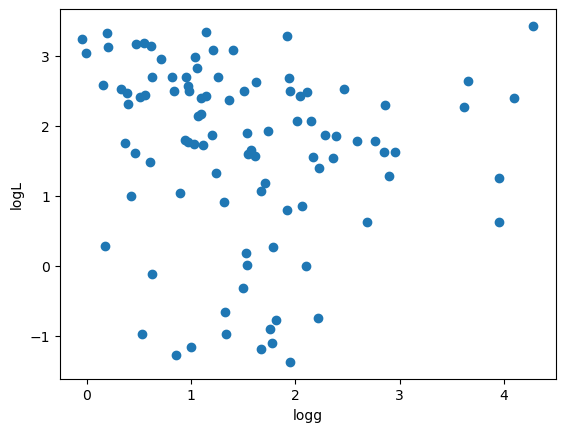

In [23]:
plt.scatter(df.logg_astra, df.log_lum_lsun) # '.')
plt.xlabel('logg')
plt.ylabel('logL')

(6000.0, 3000.0)

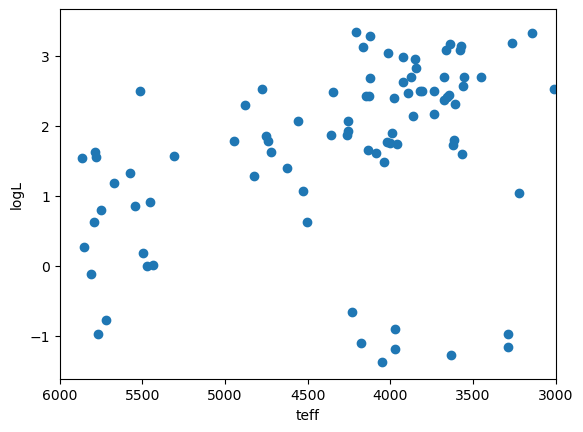

In [27]:
plt.scatter(df.teff_astra, df.log_lum_lsun) # '.')
plt.xlabel('teff')
plt.ylabel('logL')
plt.xlim(6000,3000)

(4.0, 0.0)

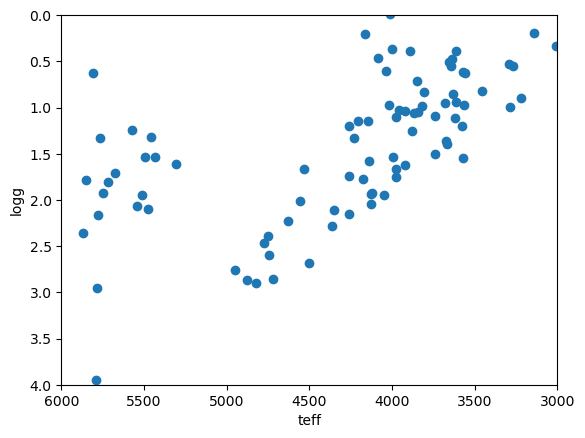

In [30]:
plt.scatter(df.teff_astra, df.logg_astra) # '.')
plt.xlabel('teff')
plt.ylabel('logg')
plt.xlim(6000,3000)
plt.ylim(4,0)

In [4]:
df = Roman.to_pandas()

In [5]:
#df

In [6]:
#set up models

In [7]:
grid = kh.load_interpolator('JT2017t11')

In [8]:
# mass, metallicity, alpha/fe, helium, mixing length, eep
star = grid.get_star_eep((1, 0, 0, 0.273,1.7, 600))
star

Age(Gyr)                  12.414234
L/Lsun                     2.440923
R/Rsun                     1.580824
logg                       1.276483
Log Teff(K)                3.581127
mass_conv_core             0.000000
mass_conv_envelope         0.665663
logT(cen)                  7.696126
logrho(cen)                5.586386
logP(cen)                 21.790877
Xcen                       0.000000
Ycen                       0.982061
Zcen                       0.017939
He lum (Lsun)              0.000000
Xsurf                      0.686363
Ysurf                      0.294359
Zsurf                      0.017939
surface_ZovrX              0.026137
Tau(cz)(sec)          350418.918407
Mass(Msun)                 1.000000
dtype: float64

In [9]:
# use grid points between ZAMS (201) and RGBump (605)
qstring = '201 <= eep'

# Whether to fit evolved metallicity (True) or use the initial metallicity.
# False is probably fine if you're not on the giant branch.
evolve_met = False

# load grid, remove unwanted rows
jtgrid = kh.load_eep_grid("JT2017t11").query(qstring)
# set column names to some standard
jtgrid['mass'] = jtgrid['Mass(Msun)']
jtgrid['teff'] = 10**jtgrid['Log Teff(K)']
jtgrid['lum'] = jtgrid['L/Lsun'] #10**
if evolve_met:
    jtgrid['met'] = np.log10(jtgrid['Zsurf']/jtgrid['Xsurf']/0.0253)
else:
    jtgrid['met'] = jtgrid.index.get_level_values('initial_met')
jtgrid['initial_he'] = jtgrid.index.get_level_values('initial_he')
jtgrid['mixing_length']= jtgrid.index.get_level_values('mixing_length')
jtgrid['alpha_fe']= jtgrid.index.get_level_values('alpha_fe')
jtgrid['age'] = jtgrid['Age(Gyr)']
# set name for readability of output
jtgrid.set_name('jtgrid')
#jtgrid
# cast to interpolator
jtgrid =jtgrid.to_interpolator()

In [10]:
def fit_all_grids(star, *args, **kwargs):
    gridnames = []
    models = []
    for gname, interp in zip(
        ['jtgrid'],
        [jtgrid]):
        model, fit = interp.gridsearch_fit(star, *args, **kwargs)
        if fit.success:
            gridnames.append(gname)
            models.append(
                model[['initial_mass', 'initial_met', 'initial_he', 'alpha_fe', 'mixing_length', 'eep', 'mass', 'teff', 'lum', 'met', 'logg', 'age']]
            )
    models = pd.concat(models, axis=1)
    models.columns = gridnames

    return models

def compute_statistics(models, exclude=None):
    stats = models.copy()
    if exclude is not None:
        stats = stats.drop(columns=exclude)

    mean = stats.mean(axis=1)
    stdev = stats.std(axis=1, ddof=1)
    max_offset = stats.max(axis=1) - stats.min(axis=1)

    stats['mean'] = mean
    stats['stdev'] = stdev
    stats['max offset'] = max_offset

    return stats

In [12]:
#helper functions to do helium, set up the kiauhoku interpolation, etc

In [11]:
def compute_y(feh, alfe,
                Xsol=0.709370,
                Ysol=0.272683,
                Zsol=0.0179471,
                Ybb=0.2484,
                alpha_to_z_coeff=0.75):


    # dY/dZ
    dYdZ = (Ysol - Ybb) / Zsol

    # Z/X implied by [Fe/H] and [alpha/Fe] 
    # -- do not know what the justification for this is 
    z_over_x = (Zsol / Xsol) * 10.0**(feh + alpha_to_z_coeff * alfe)

    # Solve analytically
    X = (1.0 - Ybb) / (1.0 + z_over_x * (1.0 + dYdZ))
    Z = z_over_x * X
    Y = Ybb + dYdZ * Z

    return Y

In [14]:
#sun1 = {'teff':5772, 'lum':0, 'met':0, 'logg':4.4, 'alpha_fe': 0, 'initial_he': 0.27}
#scale = {'teff':1000, 'lum':0, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
#models = fit_all_grids(sun1, scale=scale, tol=1e-4)
#models

In [15]:
#debugging

In [16]:
# def get_tracks(model, masses, metallicity=0.0, alpha_fe=0,  initial_he=0.272683, mixing_length=1.724485,):
#     return [model.get_track((mass, metallicity, alpha_fe,  initial_he, mixing_length)) for mass in masses]

# models = {"jtgrid": jtgrid}
# masses = [0.8,1.0,1.4,1.8,2.0]
# metallicity = 0.2
# mls=[1.224485, 1.724485, 2.224485]


# yrec_tracksm12 = get_tracks(jtgrid, masses, metallicity=metallicity, alpha_fe=0,  initial_he=0.272683, mixing_length=1.224485)
# yrec_tracksm17 = get_tracks(jtgrid, masses, metallicity=metallicity, alpha_fe=0,  initial_he=0.272683, mixing_length=1.724485)
# yrec_tracksm22 = get_tracks(jtgrid, masses, metallicity=metallicity, alpha_fe=0,  initial_he=0.272683, mixing_length=2.224485)
# #mist_tracks = get_tracks(mist, masses, metallicity=metallicity)
# #dart_tracks = get_tracks(dart, masses, metallicity=metallicity) 
# #gars_tracks = get_tracks(gars, masses, metallicity=metallicity)


# fig,arr = plt.subplots(2,2,figsize=(10,10),sharex=True,sharey=True)
# for mass, track in zip(masses[0:5], yrec_tracksm12[0:5]):
#     arr[0, 0].plot(track['teff'], track['logg'], label=f"Mass={mass:.1f}")
# for mass, track in zip(masses[0:5], yrec_tracksm17[0:5]):
#     arr[0, 1].plot(track['teff'], track['logg'])
# for mass, track in zip(masses[0:5], yrec_tracksm22[0:5]):
#     arr[1, 0].plot(track['teff'], track['logg'])
# #for mass, track in zip(masses[0:5], gars_tracks[0:5]):
# #    arr[1, 1].plot(track['teff'], track['logg'])

# arr[0, 0].annotate('Ml12',xy=(5200,2.4),xytext=(5200,2.4),size='medium')
# #arr[0, 1].annotate('MIST',xy=(5200,2.4),xytext=(5200,2.4),size='medium')
# #arr[1, 0].annotate('DSEP',xy=(5200,2.4),xytext=(5200,2.4),size='medium')
# #arr[1, 1].annotate('GARSTEC',xy=(5200,2.4),xytext=(5200,2.4),size='medium')

# arr[0,0].invert_xaxis()
# arr[0,0].set_ylim(5.0, 1.0) #3.25,2.25)
# arr[0,0].set_xlim(6000, 3000 )#5300,4500)

# for i in range(2):
#     for j in range(2): 
#         arr[i, j].grid(True, which='both', linestyle='--', linewidth=0.5)
#         arr[i, j].tick_params(axis='x', rotation=45)
#         arr[i, j].tick_params(axis='y', rotation=45)
#         arr[i, j].tick_params(axis='both', labelsize=10)

# #plot the star
# #arr[0,0].scatter(models_0b['yrec'].loc['teff'],models_0b['yrec'].loc['logg'],c='k',label='W/ spectroscopic \nparameters')
# #arr[0,1].scatter(models_0b['mist'].loc['teff'],models_0b['mist'].loc['logg'],c='k')
# ##arr[1,0].scatter(models_0b['dartmouth'].loc['teff'],models_0b['dartmouth'].loc['logg'],c='k')
# #arr[1,1].scatter(models_0b['garstec'].loc['teff'],models_0b['garstec'].loc['logg'],c='k')

# fig.text(0.05, 0.5, r'$\log(g)$', ha='center', va='center', rotation='vertical',size=18)
# fig.text(0.5, 0.02, r'T$_{eff}$ (K)', ha='center', va='center',size=18)
# fig.legend(bbox_to_anchor=(0.95, 0.8), loc='upper left', borderaxespad=0.)
# plt.subplots_adjust(hspace=0.05,wspace=0.05);
# #print(f"Grid estimated mass (Msun): \n{models_0b.loc['mass']}")

In [17]:
# yrec_tracksm22

In [18]:
# yrec_tracks = jtgrid.get_track((1.0, 0.0, 0.0, 0.272683,1.724485))
# yrec_tracks

In [19]:
# sun1 = {'teff':5772, 'lum':0, 'met':0, 'logg':4.4, 'alpha_fe': 0, 'initial_he': 0.27}
# scale = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
# models = fit_all_grids(sun1, scale=scale, tol=1e-4)
# models

In [12]:
i=0
scale1 = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
#for i in range(len(df.logg_astra)):
star1= {'teff':df.teff_astra[i], 'lum':df.log_lum_lsun[i], 'met':df.mh_astra[i], 
        'logg':df.logg_astra[i], 'alpha_fe':df.alpha_m_astra[i] , 'initial_he': compute_y(df.mh_astra[i], df.alpha_m_astra[i])}
print(star1)    


{'teff': np.float64(4823.2841796875), 'lum': np.float64(1.284656287949581), 'met': np.float64(0.27458998560905457), 'logg': np.float64(2.9006128311157227), 'alpha_fe': np.float64(-0.055950794368982315), 'initial_he': np.float64(0.2883001690154272)}


In [13]:
yn=compute_y(0.142, 0.0)
yn

0.2813583812033316

In [16]:
star4= {'teff':4776.85, 'lum':2.5357, 'met':0.1420, 
        'logg':2.4679, 'alpha_fe':0.0 , 'initial_he': 0.281}

In [17]:
scale1 = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}

In [ ]:
model4 = fit_all_grids(star4, scale=scale1, tol=1e-2)

Fitting star with jtgrid...


In [18]:
models=[]
i=0
scale1 = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
#for i in range(len(df.logg_astra)):
star1= {'teff':df.teff_astra[i], 'lum':df.log_lum_lsun[i], 'met':df.mh_astra[i], 
        'logg':df.logg_astra[i], 'alpha_fe':df.alpha_m_astra[i] , 'initial_he': compute_y(df.mh_astra[i], df.alpha_m_astra[i])}
print(star1)    
try:
    model1 = fit_all_grids(star1, scale=scale1, tol=1e-2)
    models.append(model1)
except:
    print(df.sdss_id[i], 'bad')
print(models)

{'teff': np.float64(4823.2841796875), 'lum': np.float64(1.284656287949581), 'met': np.float64(0.27458998560905457), 'logg': np.float64(2.9006128311157227), 'alpha_fe': np.float64(-0.055950794368982315), 'initial_he': np.float64(0.2883001690154272)}
Fitting star with jtgrid...
jtgrid: Fit not converged to within tolerance, but returning closest fit.
[                     jtgrid
initial_mass   1.626332e+00
initial_met    2.741172e-01
initial_he     2.900004e-01
alpha_fe       5.007824e-11
mixing_length  1.530998e+00
eep            5.427155e+02
mass           1.626332e+00
teff           4.470795e+03
lum            1.294436e+00
met            2.741172e-01
logg           2.909109e+00
age            2.427526e+00]


In [ ]:
i=4
star4= {'teff':df.teff_astra[i], 'lum':df.log_lum_lsun[i], 'met':df.mh_astra[i], 
        'logg':df.logg_astra[i], 'alpha_fe':0.0 , 'initial_he': compute_y(df.mh_astra[i], df.alpha_m_astra[i])}
print(star4)
model4 = fit_all_grids(star4, scale=scale1, tol=1e-2)

{'teff': np.float64(4776.8583984375), 'lum': np.float64(2.535737059450402), 'met': np.float64(0.14202000200748444), 'logg': np.float64(2.467907190322876), 'alpha_fe': 0.0, 'initial_he': np.float64(0.2774823169388763)}
Fitting star with jtgrid...


In [18]:
fitstars=np.array(models)
masses_mlfit=fitstars[:,0].reshape(-1)
ml_mlfit=fitstars[:,4].reshape(-1)
lum_mlfit=fitstars[:,8].reshape(-1)
ages_mlfit=fitstars[:,11].reshape(-1)

In [30]:
testdf= np.array((np.squeeze(fitstars)))#.T
np.savetxt('mixinglength_KHfit_try1.csv', testdf, delimiter=',')
#testdf.to_csv('mixinglength_KHfit_try1.csv')

In [ ]:
dfmodels['age_tefffit'] = [masses_mlfit.tolist(), ml_mlfit.tolist(), lum_mlfit
dfmodels.to_csv('mixinglength_KHfit_try1.csv')

In [19]:
lum_mlfit

array([1.29443576])

In [ ]:
models

In [ ]:
#this below is the thing that should work and for some reason star 0 works, star 1 fails,
#and star 2 crashes the kernel

In [ ]:
models=[]

scale1 = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
for i in range(len(df.logg_astra)):
    star1= {'teff':df.teff_astra[i], 'lum':df.log_lum_lsun[i], 'met':df.mh_astra[i], 
        'logg':df.logg_astra[i], 'alpha_fe':df.alpha_m_astra[i] , 'initial_he': compute_y(df.mh_astra[i], df.alpha_m_astra[i])}
    
    try:
        model1 = fit_all_grids(star1, scale=scale1, tol=1e-2)
        models.append(model1)
    except:
        print(df.sdss_id[i], 'bad')

Fitting star with jtgrid...


In [21]:
#yn=compute_y(0.27, 0.0111)
#yn

0.2922779724045709

In [ ]:
fitstars=np.array(models)
masses_tefffit=fitstars[:,3].reshape(-1)
ages_tefffit=fitstars[:,9].reshape(-1)
rot_tefffit=fitstars[:,8].reshape(-1)
tefffit=fitstars[:,4].reshape(-1)

print( np.array((np.squeeze(fitstars))).T)

df['age_tefffit'] = ages_tefffit.tolist()
df.to_csv('mixinglength_KHfit_try1.csv')

In [34]:
# # mass, metallicity, alpha/fe, helium, mixing length, eep
# star = grid.get_star_eep((1, 0.39, 0.0111, yn,1.7, 455))
# star

In [35]:
# starb= {'teff':4723, 'mass':1.0, 'met':0.27, 'logg':2.90, 'alpha_fe': 0.0111, 'initial_he': yn}
# scale1 = {'teff':1000, 'mass':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
# models = fit_all_grids(starb, scale=scale1, tol=1e-4)
# models

In [36]:
# starN= {'teff':4723, 'lum':1.2846, 'met':0.27, 'logg':2.90, 'alpha_fe': 0.0111, 'initial_he': 0.2922}
# scale1 = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
# # models = fit_all_grids(starN, scale=scale1, tol=1e-4)
# models

In [37]:
# startest={'logg': 2.55, 'teff': 4459.8955078125, 'lum': 12.7441121252139, 'met': -1.32, 'alpha_fe': 0, 'initial_he': 0.26658634461966374}
# model1=fit_all_grids(startest) #, scale={0.1, 1000, 10, 0.1, 0.1, 0.1}, tol=1e-4)

In [38]:
# startest={'logg': 1.55, 'teff': 4159, 'lum': 43, 'met': -0.132, 'alpha_fe': 0, 'initial_he': 0.26}
# model1=fit_all_grids(startest)

In [ ]:
#end debugging

In [ ]:
#for each star in the dataset, compute things where possible
#run a loop to fit a mixing length for all the stars that don't have blanks or nans in their best lists (eyeroll)

In [43]:
# models=[]
# for i in range(len(df.logg_best)):
#     if ((df.logg_best[i]==df.logg_best[i]) & 
#               (df.teff_best[i]==df.teff_best[i]) &
#               (df.luminosity_best_lsun[i]==df.luminosity_best_lsun[i]) &
#               (df.metallicity_best[i]==df.metallicity_best[i])):
#                     alphafe=0
#                     ystar=compute_y(df.metallicity_best[i], alphafe)
                
#                     star={'logg':df2.logg_best[i], 'teff':df2.teff_best[i], 'lum':df2.luminosity_best_lsun[i], 
#                           'met':df2.metallicity_best[i],'alpha_fe':alphafe, 'initial_he':ystar}
#                     scale1 = {'teff':1000, 'lum':0.1, 'met':0.1, 'logg':0.1, 'alpha_fe':0.1, 'initial_he':0.01}
#                     print(star)
#                     model1=fit_all_grids(star, scale=scale1, tol=1e-3)
#                     models.append(model1)

In [ ]:
models

In [ ]:
#still needs work below here

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed